<a href="https://colab.research.google.com/github/diak224-dot/Machine-Learning-Projects/blob/main/DIAK_test4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print(np.array(X_train,dtype=object).shape)
print(y_train.shape)
print(np.unique(y_train))
print(len(X_train[0]))
print(len(X_train[1]))
print(X_train[0][:20])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000,)
(25000,)
[0 1]
218
189
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]


## Réponses aux questions

1. Le dataset contient 25 000 critiques d'entraînement et 25 000 critiques de test.
2. Les nombres représentent des indices de mots dans le vocabulaire IMDB.
3. X_train contient les critiques tandis que y_train contient les étiquettes.
4. Il s'agit d'une classification binaire car il existe deux classes : positive et négative.


# Partie 2 – Padding

In [3]:
max_len = 200

X_train = pad_sequences(X_train,maxlen=max_len)
X_test = pad_sequences(X_test,maxlen=max_len)

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

print(X_train.shape)
print(X_test.shape)
print(X_train[0])


(25000, 200)
(25000, 200)
[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  113 

## Réponses aux questions

1. Les RNN nécessitent des séquences de même taille dans un batch.
2. pad_sequences uniformise les longueurs.
3. Les longues séquences sont tronquées.
4. Les courtes séquences sont complétées par des zéros.
5. Les zéros observés correspondent au padding.
6. Le one-hot n'est pas nécessaire en classification binaire.


# Partie 3 – Visualisation et décodage

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole story was so lovely because it was true and was someone'

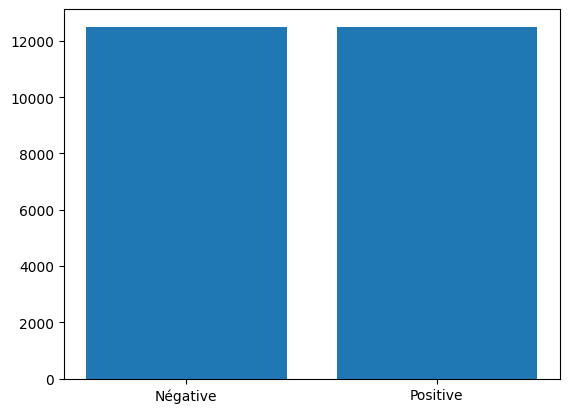

In [4]:
word_index = imdb.get_word_index()
reverse_word_index = {v:k for k,v in word_index.items()}

def decode_review(seq):
    return " ".join(reverse_word_index.get(i-3,"?") for i in seq)

for i in range(5):
    print("="*80)
    print(decode_review(X_train[i]))
    print("Label :", "Positive" if y_train[i]==1 else "Négative")

neg = np.sum(y_train==0)
pos = np.sum(y_train==1)

plt.bar(["Négative","Positive"],[neg,pos])
plt.show()

## Réponses aux questions

1. Le décodage permet de comprendre les données.
2. Les critiques positives contiennent souvent des termes valorisants.
3. Les indices 0,1,2 sont réservés par Keras.
4. Sans décalage de 3, le texte décodé serait incorrect.
5. Le dataset est équilibré, ce qui facilite une évaluation fiable.


# Partie 4 – Construction du modèle RNN

In [5]:
model = Sequential()

model.add(Embedding(input_dim=10000, output_dim=32, input_length=200))
model.add(SimpleRNN(32, activation="tanh"))
model.add(Dense(1, activation="sigmoid"))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Réponses aux questions

1. La taille d'entrée dépend de la longueur des séquences.
2. Embedding apprend une représentation vectorielle des mots.
3. tanh stabilise les activations.
4. L'état caché mémorise le contexte précédent.
5. sigmoid est adaptée à deux classes. tanh stabilise les activations.
4. L'état caché mémorise le contexte précédent.
5. sigmoid est adaptée à deux classes.


# Partie 5 – Compilation

In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Réponses aux questions

1. La fonction de perte mesure l'erreur.
2. binary_crossentropy est adaptée à la classification binaire.
3. Adam ajuste automatiquement le taux d'apprentissage.
4. Accuracy mesure le pourcentage de bonnes prédictions.


# Partie 6 – Entraînement

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.5878 - loss: 0.6686 - val_accuracy: 0.6302 - val_loss: 0.6435
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.7847 - loss: 0.4756 - val_accuracy: 0.8274 - val_loss: 0.4015
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.8904 - loss: 0.2807 - val_accuracy: 0.8030 - val_loss: 0.4268
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9462 - loss: 0.1589 - val_accuracy: 0.8022 - val_loss: 0.4506
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.9790 - loss: 0.0781 - val_accuracy: 0.8234 - val_loss: 0.4659
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9898 - loss: 0.0423 - val_accuracy: 0.8298 - val_loss: 0.4856
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9961 - loss: 0.0204 - val_accuracy: 0.8484 - val_loss: 0.5795
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9968 - loss: 0.0168 - 

## Réponses aux questions

1. Une époque correspond à un passage complet sur les données.
2. batch_size contrôle le nombre d'exemples traités simultanément.
3. La validation mesure la généralisation.
4. Trop d'époques peuvent provoquer le surapprentissage.
5. Les RNN sont plus lents car ils traitent les données séquentiellement.


# Partie 7 – Courbe de perte

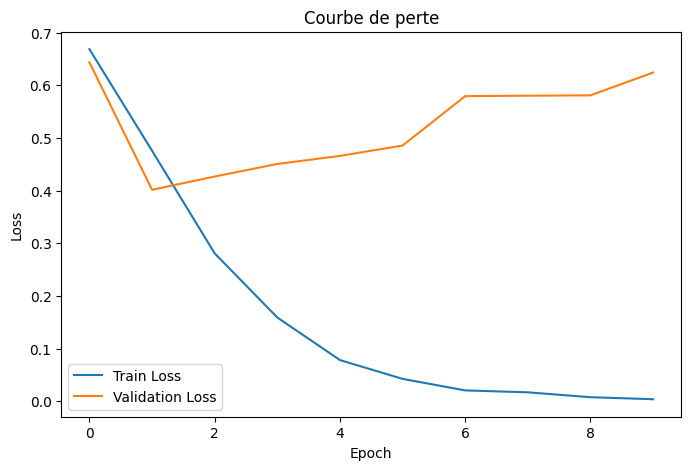

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe de perte")
plt.show()

## Interprétation

Insérer ici votre capture d'écran et commenter :
- diminution de la perte ;
- convergence ;
- présence ou non de surapprentissage.


# Partie 8 – Évaluation

In [10]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)

print("Test Loss :",test_loss)
print("Test Accuracy :",test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8294 - loss: 0.6432
Test Loss : 0.6432189345359802
Test Accuracy : 0.8294399976730347


## Réponses aux questions

1. Le test mesure la généralisation.
2. L'accuracy de test est plus représentative.
3. Une accuracy élevée indique de bonnes prédictions.
4. L'accuracy seule ne suffit pas toujours.


# Partie 9 – Rapport de classification

In [11]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob>0.5).astype("int32").flatten()

print("Accuracy :",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred,target_names=["Négative","Positive"]))


782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step
Accuracy : 0.82944
              precision    recall  f1-score   support

    Négative       0.84      0.82      0.83     12500
    Positive       0.82      0.84      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



## Réponses aux questions

1. Le modèle retourne des probabilités.
2. Le seuil 0.5 décide de la classe finale.
3. La précision mesure la fiabilité des prédictions positives.
4. Le rappel mesure la capacité à retrouver les positifs.
5. Le F1-score combine précision et rappel.


# Partie 10 – Matrice de confusion

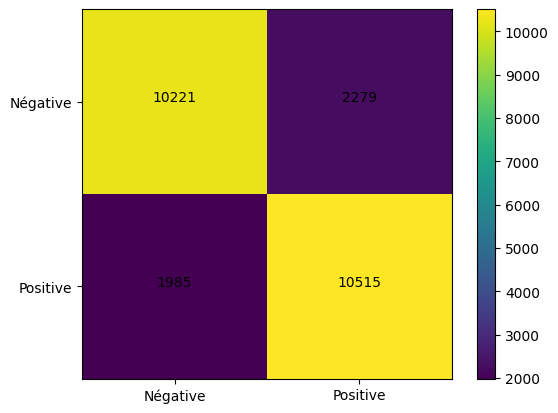

In [12]:
cm = confusion_matrix(y_test,y_pred)

plt.imshow(cm)
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha="center")

plt.xticks([0,1],["Négative","Positive"])
plt.yticks([0,1],["Négative","Positive"])
plt.show()


## Réponses aux questions

1. La matrice de confusion résume les bonnes et mauvaises classifications.
2. Elle met en évidence VP, VN, FP et FN.
3. Elle permet d'identifier les erreurs du modèle.
4. Les critiques ambiguës sont souvent confondues.
5. Elle aide à améliorer le modèle.


# Conclusion générale

Le RNN a permis d'effectuer une classification de sentiments sur le dataset IMDB. Les résultats obtenus montrent la capacité des réseaux récurrents à exploiter la nature séquentielle du texte pour distinguer efficacement les critiques positives et négatives.

**Ajouter ici les captures d'écran demandées par l'enseignant :**
- Distribution des classes
- Model Summary
- Courbe Loss/Val Loss
- Accuracy finale
- Classification Report
- Matrice de confusion